# FERTILITY CLASSSIFIER

Importing necessary libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math


In [34]:
# ENCODING the values


df=pd.read_csv('fertility.csv')

def assign_age(age):
    if age <28:
        return 3
    elif 28<= age <=36 :
        return 2
    elif 36<= age <=45:
        return 1
    else:
        return 0

df['Age']=df['Age'].apply(assign_age)
df['Season'] = df['Season'].map({'winter':-1,'spring':-0.33,'summer':0.33,'fall':1})

df['Childish diseases']=df['Childish diseases'].map({'yes':0,'no':1})
df['Accident or serious trauma']=df['Accident or serious trauma'].map({'yes':0,'no':1})
df['Surgical intervention']=df['Surgical intervention'].map({'yes':0,'no':1})
df['High fevers in the last year'] = df['High fevers in the last year'].map({'less than 3 months ago':-1,'more than 3 months ago':0,'no':1})
df['Frequency of alcohol consumption']=df['Frequency of alcohol consumption'].map({'several times a day':-1.5,'every day':-1,'several times a week':-0.5,'once a week':-0.25,'hardly ever or never':1})
df['Smoking habit'] = df['Smoking habit'].map({'never':-1, 'occasional':0, 'daily': 1})
df['Number of hours spent sitting per day'] = (df['Number of hours spent sitting per day'] - df['Number of hours spent sitting per day'].min()) / (df['Number of hours spent sitting per day'].max() - df['Number of hours spent sitting per day'].min())


X_features = df.drop(columns='Diagnosis').values
Y_output = df['Diagnosis'].map({'Normal':0, 'Altered':1}).values

indices=np.random.permutation(len(X_features))
train_size= int(0.7* len(X_features))

X_train=X_features[indices[:train_size]]
y_train=Y_output[indices[:train_size]]

X_test=X_features[indices[train_size:]]
y_test=Y_output[indices[train_size:]]




In [36]:
df.head(7)

,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,-0.33,2,1,0,0,0,-0.25,0,0.043988,Normal
1,-0.33,2,0,1,0,0,-0.25,1,0.014663,Altered
2,-0.33,3,0,1,1,0,1.00,-1,0.023460,Normal
3,-0.33,2,1,0,0,0,1.00,-1,0.017595,Normal
4,-0.33,2,0,0,1,0,-0.25,-1,0.023460,Altered
5,-0.33,2,0,1,0,0,-0.25,0,0.023460,Normal
6,-0.33,2,1,1,1,-1,-0.25,-1,0.020528,Normal


In [6]:
print(X_train[:5])

[[-0.33        2.          0.          1.          1.          1.
   1.          1.          0.        ]
 [-1.          2.          0.          1.          0.         -1.
  -0.25        1.          0.02346041]
 [-1.          2.          0.          1.          1.          1.
  -0.25       -1.          0.01466276]
 [-0.33        2.          0.          1.          0.          0.
  -0.25        1.          0.0058651 ]
 [-0.33        2.          0.          0.          1.          0.
  -0.25       -1.          0.02346041]]


In [38]:
def sigmoid(z):
    y= 1 + np.exp(-z)
    y=1/y
    return y

In [70]:
def cost_funcn(X_train,y_train,w,b,*argv):

    m,n=X_train.shape
    cost=0.
    for i in range(m):
        z = np.dot(w,X_train[i]) + b
        #f_x_i = sigmoid(z)
        f_x_i = np.clip(sigmoid(z), 1e-9, 1 - 1e-9)
        cost+= (-y_train[i]) * np.log(f_x_i) - ((1 - y_train[i]) * np.log(1 - f_x_i))

    return cost/m


    

In [48]:
m,n=X_train.shape
initial_w=np.array([0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2])
initial_b=-24.
print(cost_funcn(X_train[:50],y_train[:50],initial_w,initial_b))

2.072326584594642


In [28]:
print(df['High fevers in the last year'].unique())

[ 0 -1  1]


In [50]:
def compute_gradient(X_train,y_train,w,b):
    
    m,n=X_train.shape
    dj_dw=np.zeros(n)
    dj_db=0.0

    for i in range(m):
        f_x_i=sigmoid(np.dot(w,X_train[i]) + b)
        error=f_x_i - y_train[i]

        for j in range(n):
            dj_dw[j] = dj_dw[j] + (error * X_train[i,j])
        dj_db= dj_db + error

    dj_dw=dj_dw/m
    dj_db=dj_db/m
    return dj_dw,dj_db


    
    

In [122]:
def gradient_descent(X_train,y_train,w,b,cost_funcn,compute_gradient,num_iter,alpha,lambda_):

    m=len(X_train)
    J_history = []
    for i in range(num_iter):
        dj_dw,dj_db=compute_gradient(X_train,y_train,w,b)

        w= w - alpha*dj_dw
        b= b - alpha*dj_db
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_funcn(X_train, y_train, w, b, lambda_)
            J_history.append(cost)
        if i % 1000 == 0:
            print(f"Iteration {i:4}: Cost {cost:.4f}")
        
    return w, b, J_history
        
    

In [206]:
initial_w = np.random.randn(9) * 0.1  # Larger random initialization
initial_b = 0  # Set bias to 0
# Some gradient descent settings
num_iters = 50000
alpha = 0.1

w,b, J_history = gradient_descent(X_train ,y_train, initial_w, initial_b, 
                                   cost_funcn, compute_gradient, iterations, alpha, 0)

Iteration    0: Cost 0.6900
Iteration 1000: Cost 0.3143
Iteration 2000: Cost 0.3125
Iteration 3000: Cost 0.3122
Iteration 4000: Cost 0.3120
Iteration 5000: Cost 0.3118
Iteration 6000: Cost 0.3117
Iteration 7000: Cost 0.3116
Iteration 8000: Cost 0.3115
Iteration 9000: Cost 0.3114


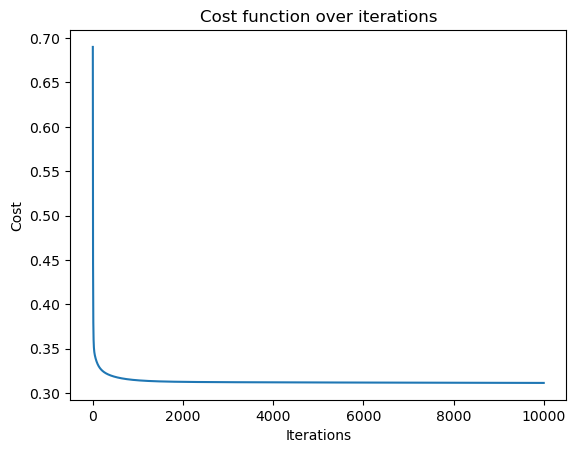

In [207]:
# Plot the cost function over iterations
plt.plot(J_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost function over iterations')
plt.show()

In [208]:
print(f"Cost at iteration 9500: {J_history[-1]:.4f}")
print(f"Cost at iteration 10000: {J_history[-1]:.4f}")

Cost at iteration 9500: 0.3113
Cost at iteration 10000: 0.3113


In [209]:
print(w,b)

[ 0.53888342 -1.57228762 -0.82465621  1.38813666 -0.10645616  0.02319414
 -0.87200933 -0.19489397 -0.24584374] 0.39657144049074916


In [210]:
def predict(X,w,b):
    predictions=sigmoid(np.dot(X,w)+b)
    return predictions
    

In [211]:
predictions=predict(X_test,w,b)

# Optionally, you can round the predictions to 0 or 1 for binary classification:
predictions = np.round(predictions)

# Calculate performance metrics such as accuracy
accuracy = np.mean(predictions == y_test)
print(f"Model Accuracy on Test Data: {accuracy * 100:.2f}%")

Model Accuracy on Test Data: 86.67%


In [212]:
# Get predictions on the test set
predictions = predict(X_test, w, b)

# Round the predictions to 0 or 1 for binary classification (if applicable)
predictions = np.round(predictions)

# Select a few rows to compare (for example, first 10 rows)
num_rows_to_compare = 10
comparison = np.vstack((y_test[:num_rows_to_compare], predictions[:num_rows_to_compare])).T

# Print actual vs predicted values
print("Actual vs Predicted values (first 10 rows):")
print(comparison)

Actual vs Predicted values (first 10 rows):
[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [1. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


In [190]:
print(J_history[-10:])  # Print the last 10 cost function values to see if it's decreasing

[0.3118343393924528, 0.31183427728550633, 0.31183421518209753, 0.3118341530822257, 0.3118340909858894, 0.31183402889308803, 0.31183396680382014, 0.311833904718085, 0.31183384263588104, 0.31183378055720795]
